# Module 6 — Semantic Search and RAG

### Setup

*these will be present in the beginning of all the notebooks to make sure the environment is setup correctly in colab*

#### Setup Notebook Environment

### Installing Python libraries

**In Colab**, this might ask you to restart your session, do so and if you face issues that Gemini can't help you with ask the TA.

In [1]:
import pkg_resources
try:
    import google.colab
    IN_COLAB = True
    print("Running on Colab, let's run through the installs")
except ImportError:
    IN_COLAB = False
    print("Running locally, assuming you have a venv setup already done.")

def check_and_get_missing(requirements):
    to_install = []
    for pkg, ver in requirements.items():
        try:
            installed = pkg_resources.get_distribution(pkg).version
            if ver and installed != ver:
                print(f"Version mismatch for {pkg}: found {installed}, need {ver}")
                to_install.append(f"{pkg}=={ver}")
        except pkg_resources.DistributionNotFound:
            print(f"Package {pkg} not found.")
            to_install.append(f"{pkg}=={ver}" if ver else pkg)
    return to_install

if IN_COLAB:
    # 1. PYTORCH CHECK
    torch_reqs = {"torch": "2.2.0", "torchvision": "0.17.0", "torchaudio": "2.2.0"}
    missing_torch = check_and_get_missing(torch_reqs)
    if missing_torch:
        print("Uninstalling potentially conflicting torch packages...")
        !pip uninstall -y torch torchvision torchaudio
        print("Installing correct PyTorch versions...")
        !pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 --index-url https://download.pytorch.org/whl/cu121

    # 2. CORE LIBRARIES CHECK
    core_reqs = {
        "chromadb": "0.5.5",
        "transformers": "5.5.4",
        "numpy": "1.26.4",
        "posthog": "2.5.0",
        "ollama": None
    }
    missing_core = check_and_get_missing(core_reqs)
    if missing_core:
        print(f"Installing/Updating: {missing_core}")
        !pip install -U {' '.join(missing_core)}

    # 3. UNSLOTH CHECK
    try:
        import unsloth
    except ImportError:
        print("Installing Unsloth...")
        !pip install --no-cache-dir unsloth

    import torch
    print("Final Check - Torch:", torch.__version__, "CUDA:", torch.version.cuda)

/tmp/ipykernel_10924/3350433716.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Running on Colab, let's run through the installs
Version mismatch for torch: found 2.2.0+cu121, need 2.2.0
Version mismatch for torchvision: found 0.17.0+cu121, need 0.17.0
Version mismatch for torchaudio: found 2.2.0+cu121, need 2.2.0
Uninstalling potentially conflicting torch packages...
Found existing installation: torch 2.2.0+cu121
Uninstalling torch-2.2.0+cu121:
  Successfully uninstalled torch-2.2.0+cu121
Found existing installation: torchvision 0.17.0+cu121
Uninstalling torchvision-0.17.0+cu121:
  Successfully uninstalled torchvision-0.17.0+cu121
Found existing installation: torchaudio 2.2.0+cu121
Uninstalling torchaudio-2.2.0+cu121:
  Successfully uninstalled torchaudio-2.2.0+cu121
Installing correct PyTorch versions...
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.2.0%2Bcu121-cp312-cp312-linux_x86_64.whl (757.2 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.17.0%2Bcu121-cp

Get Ollama (this is what we are using to interact with the model and manage it)

In [2]:
import subprocess
import os
import glob

def _is_already_installed(service_name: str) -> bool:
    result = subprocess.run(['which', service_name], capture_output=True)
    if result.returncode == 0:
        print(service_name, " already installed")
        return True
    return False

def find_course_dir_gdrive() -> str:
    matches = [
        os.path.dirname(m)
        for m in glob.glob('/content/drive/**/pyproject.toml', recursive=True)
        if 'applied-ml-course' in open(m).read()
    ]
    if not matches:
        return input("Please enter the correct path to 'student_scaffolding' folder in your Google Drive: ")
    return matches[0]


if IN_COLAB:
    !sudo apt-get install zstd
    if not _is_already_installed("ollama"):
        # Install Ollama
        !curl -fsSL https://ollama.com/install.sh | sh


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (5,246 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 122412 files and directories currently

Getting the data and making sure we are in the right root directory.

There are two recommended ways,
- Upload to drive from your local using "setup assistant"
- Use github with PAT token

While we have tried to accommodate different styles of working there might still be exceptions and ways of doing this that we might have skipped to test.

**Getting the PAT from Github**

Documentation: https://dev.to/warnerbell/how-to-generate-a-github-personal-access-token-pat-1bg5

Options:
  - Choose Classic Token
  - Give access to repo

In [3]:
if IN_COLAB:
    import os
    import subprocess
    import zipfile
    import getpass

    # ----------------------------
    # CONFIG
    # ----------------------------
    REPO_URL = "https://github.com/Aggregate-Intellect/watspeed-llm-course-student-repo.git"
    TARGET_DIR = "/content/repo"

    # Optional: set to None or a branch name
    REPO_BRANCH = None  # or None for main

    # ----------------------------
    # MENU
    # ----------------------------
    print("""
    📦 Project Loader Options:

    1 - Auto (Drive → Git → ZIP)
    2 - Git only
    3 - ZIP upload
    """)

    choice = input("Enter choice (1, 2, 3): ").strip()

    # ----------------------------
    # DRIVE (optional)
    # ----------------------------
    def try_drive():
        try:
            from google.colab import drive
            drive.mount('/content/drive')

            default_path = "/content/drive/MyDrive/watspeed_llm_course"
            if os.path.exists(default_path):
                print(f"📁 Default path found: {default_path}")
                return default_path

            print("🔄 Searching Google Drive...")

            path = find_course_dir_gdrive()  # optional external helper

            if path:
                print(f"📁 Drive found: {path}")
                return path

        except Exception as e:
            print("⚠️ Drive failed:", e)

        return None


    # ----------------------------
    # GIT (MAIN + BRANCH SUPPORT)
    # ----------------------------
    def try_git(repo_url, branch=None):
        try:
            if os.path.exists(TARGET_DIR):
                print("📁 Repo already exists, reusing...")
                return TARGET_DIR

            # default branch = main
            branch = branch or "main"

            print(f"🔄 Cloning repo (branch: {branch})...")

            def run_clone(url):
                return subprocess.run(
                    ["git", "clone", "--branch", branch, "--single-branch", url, TARGET_DIR],
                    text=True,
                    capture_output=True
                )

            # 1) try public clone
            result = run_clone(repo_url)

            if result.returncode == 0:
                return TARGET_DIR

            print("⚠️ Public clone failed. Trying PAT...")

            # 2) PAT fallback
            token = getpass.getpass("🔐 Enter GitHub PAT: ")

            auth_url = repo_url.replace(
                "https://", f"https://{token}:x-oauth-basic@"
            )

            result = run_clone(auth_url)

            if result.returncode == 0:
                return TARGET_DIR

            print("❌ Git clone failed")
            print(result.stderr)
            return None

        except Exception as e:
            print("⚠️ Git error:", e)
            return None


    # ----------------------------
    # ZIP IMPORT
    # ----------------------------
    def try_zip():
        print("📦 Upload ZIP...")
        from google.colab import files

        uploaded = files.upload()
        if not uploaded:
            print("⚠️ No file uploaded")
            return None

        zip_file = list(uploaded.keys())[0]

        try:
            with zipfile.ZipFile(zip_file, 'r') as z:
                z.extractall("/content")
        except zipfile.BadZipFile:
            print("❌ Invalid ZIP file")
            return None

        folder = zip_file.replace(".zip", "")
        path = os.path.join("/content", folder)

        print(f"📁 Extracted: {path}")
        return path


    # ----------------------------
    # MAIN LOGIC
    # ----------------------------
    project_path = None

    if choice == "2":
        project_path = try_git(REPO_URL, REPO_BRANCH)

    elif choice == "3":
        project_path = try_zip()

    else:
        # AUTO MODE
        project_path = try_drive()

        if not project_path:
            project_path = try_git(REPO_URL, REPO_BRANCH)

        if not project_path:
            project_path = try_zip()


    # ----------------------------
    # FINAL STEP
    # ----------------------------
    if project_path and os.path.exists(project_path):
        try:
            os.chdir(project_path)
            print("✅ Active directory:", os.getcwd())
            print("📂 Contents:", os.listdir())
        except Exception as e:
            print("❌ Failed to switch directory:", e)
    else:
        print("❌ No project loaded")

else:
    def in_root_folder() -> bool:
        return os.path.isdir("notebooks") and os.path.isdir("data")

    if not in_root_folder():
        import os
        os.chdir("..")


    📦 Project Loader Options:

    1 - Auto (Drive → Git → ZIP)
    2 - Git only
    3 - ZIP upload
    
Enter choice (1, 2, 3): 2
🔄 Cloning repo (branch: fix/technical-issues-review)...
⚠️ Public clone failed. Trying PAT...
🔐 Enter GitHub PAT: ··········
✅ Active directory: /content/repo
📂 Contents: ['CLAUDE.md', 'README.md', '.git', 'src', 'notebook_image_catalogue.md', 'uv.lock', 'notebooks', 'upload_to_colab.sh', '.claude', 'pyproject.toml', '.gitignore', 'technical_issues.md', 'prompts', 'course_setup.md', 'data', 'project_structure.md', '.python-version']


In [4]:
from IPython.display import display, Markdown

#### Start Ollama and Load the model

In [5]:
if IN_COLAB:
    import subprocess, time
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(3)  # give it a moment to start

!ollama pull gemma2:2b

In [6]:
import ollama

ollama.generate(
    model="gemma2:2b",
    prompt="hi, who is out there?"
).response

"Hello! 👋 \n\nI'm Gemma, an AI assistant created by the Google DeepMind team.  😊  What can I help you with today? \n"

---

## RAG: The Right Context at the Right Time

In Module 3 we added a retrieval layer to our classifier. We embedded labeled recipes into a ChromaDB vector store and, for each new query, retrieved the *k* nearest labeled examples to inject as few-shot context. The model didn't have those examples baked in — we fetched the most relevant ones on demand.

That was **RAG for example selection** — the few-shots that help most depend on the query, so we picked them at runtime instead of hard-coding a fixed set.

This week we're solving a different problem: **the right personalisation context changes per query and per user**, so it can't be written into the system prompt in advance.

The Module 5 adapter improved accuracy on hard cases — but skill level is still a static label the user provides. What if we inferred it from evidence instead? What if, instead of the user saying "I'm a beginner," the system looked at the last 10 recipes they've cooked and decided for itself?

That's **RAG for personalisation / quality**: retrieving context that makes the answer more accurate and more tailored to this specific user and this specific query , i.e., it changes the probability distribution from which the LLM is going to pick the next token.

---
## Where is RAG useful

Before reaching for retrieval, ask where the context belongs:


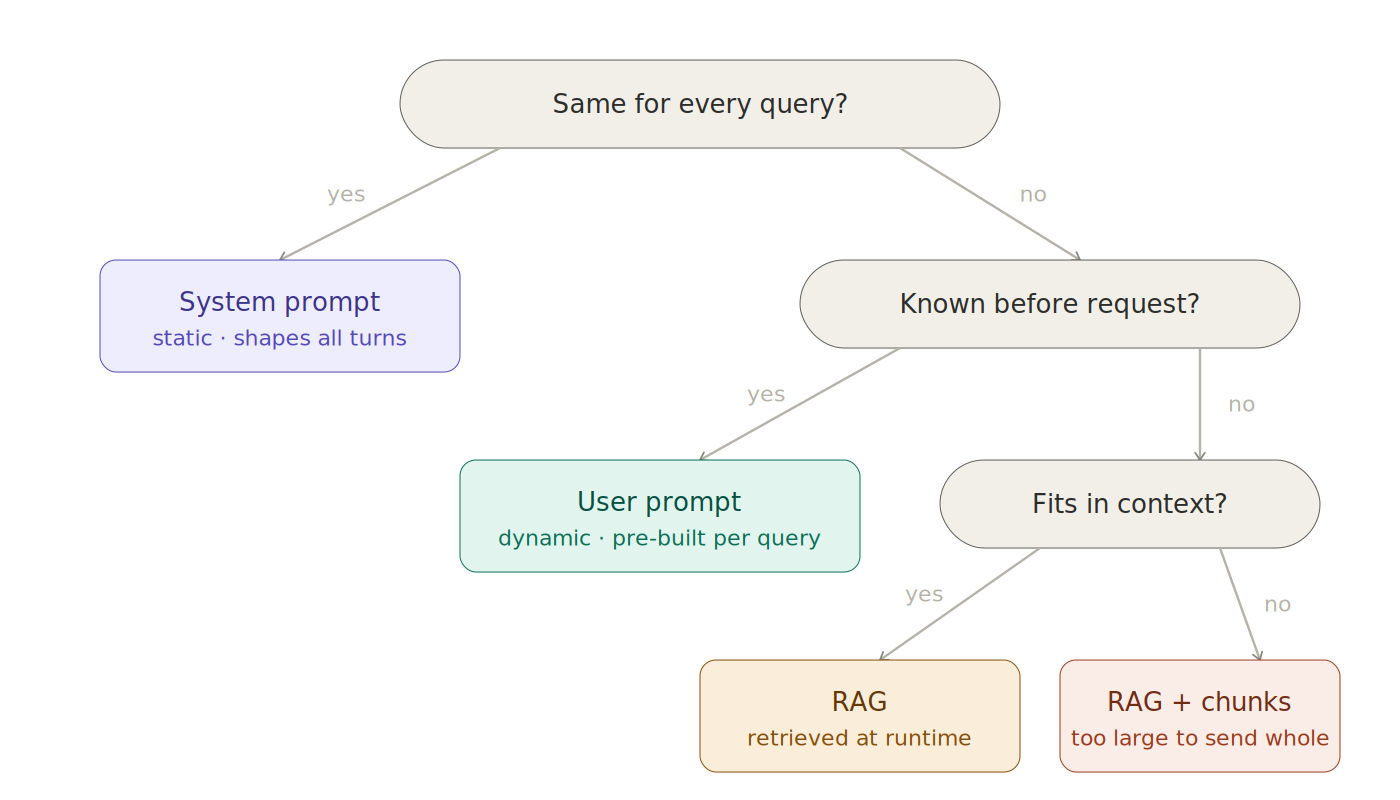

Let's look at the information we have been using so far,

**Examples from our recipe classifier:**

| Context | Where it belongs | Reason |
|---|---|---|
| Category definitions (A/B/C) | System prompt | Same for every query |
| Few-shot examples | System prompt or user prompt | Same for every query — but expensive to send every time (Option A problem from Module 5) |
| Cook's skill level | **RAG** | Changes per user — and self-report is unreliable |
| Why a technique is hard for this cook | **RAG** | The context changes per recipe |

Next, we expand our context with Cook's skill level and cooking techniques

---
## Two Retrieval Layers: User Profile + Domain Knowledge

We'll build two separate retrieval layers and combine them at the end.

**Layer 1:** Embed user cooking history → retrieve nearest user profile → infer skill level dynamically.

**Layer 2:** Chunk a technique reference document → enrich chunks with metadata → retrieve technique context personalized to the user's skill level.

**Combined:** a single classifier call that knows both *who the user is* and *what makes this recipe hard for them specifically*.

*Layer 1 answers* who *; Layer 2 answers* what's hard *; combined, the classifier gets per-user, per-recipe context the base model never had.*

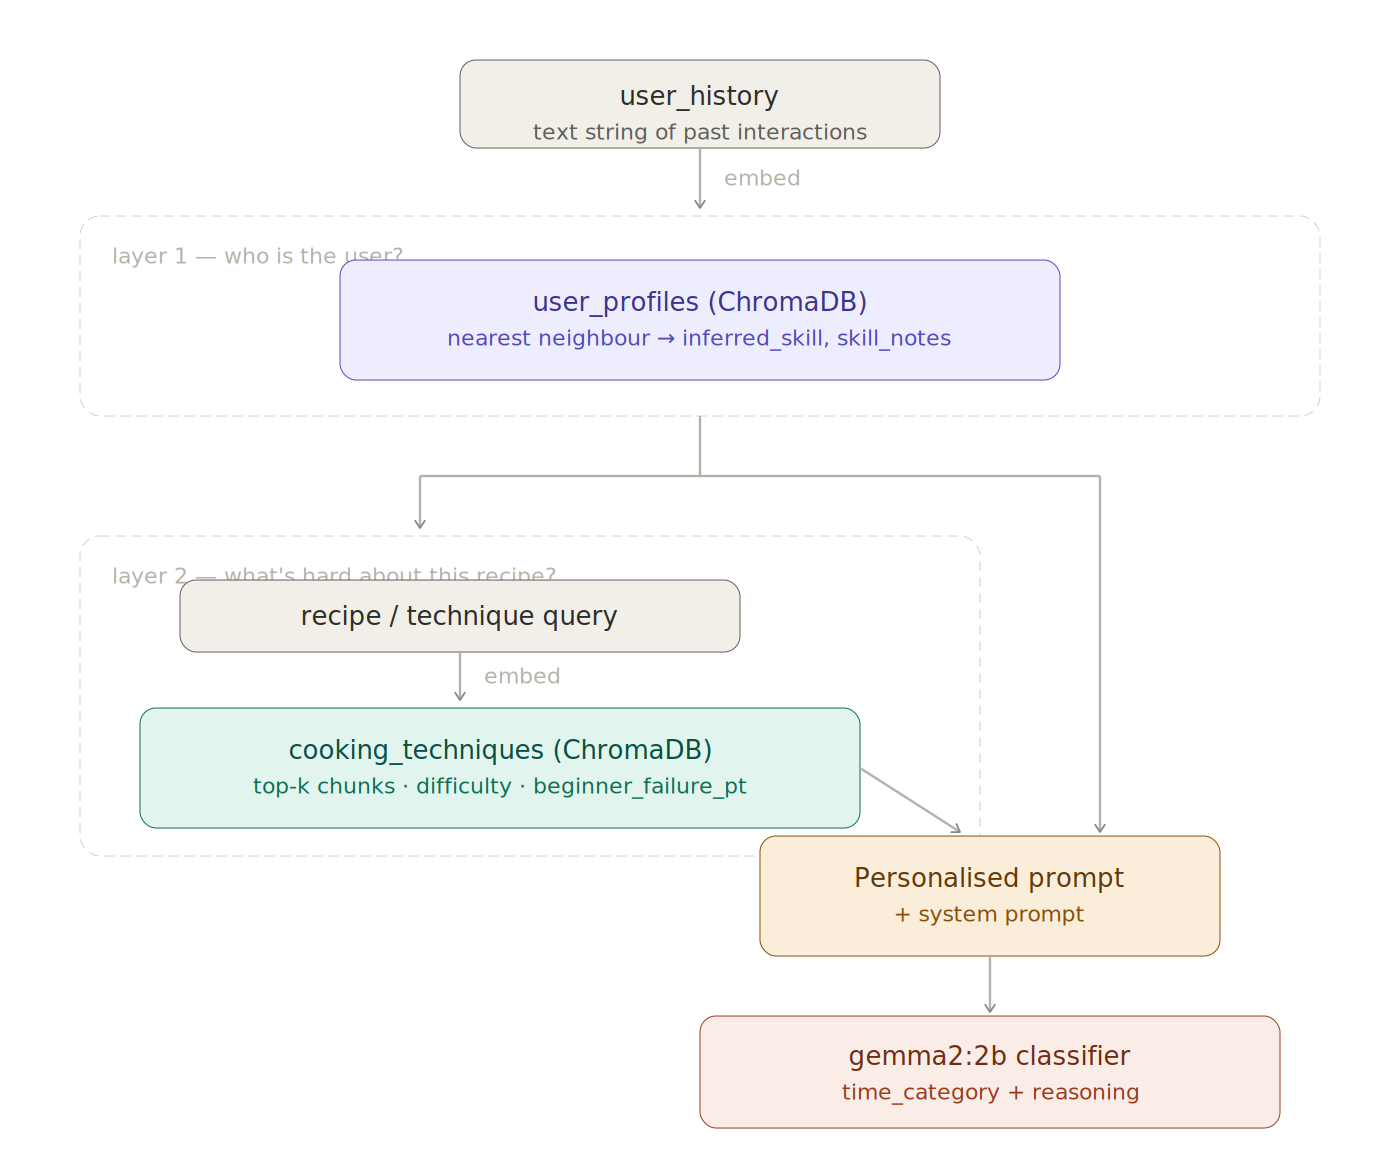

---
### Layer 1 — User History to Dynamic Skill Profile

Instead of asking users to self-report their skill level, we embed their cooking history and retrieve the nearest profile at inference time.

We'll define three reference users whose skill profiles we know, embed them into a vector store, then show how a new user's history maps to a skill level automatically.(For the scope of the notebook we are going to create our own dummy data below)

**define the data to retrieve over.**

Before we can *retrieve* a profile, we need profiles to retrieve. The cell below defines three reference users — Alice, Bob, Carol — each one a canonical persona at a known skill level, with a short cooking history and notes about where they typically struggle.

In a real system these would come from a user-activity database (last 50 dishes a user logged, ratings, timing data, etc.). Here they're hardcoded but the retrieval pattern is identical: each user's history is the *document*, and a new user's history is the *query*.


In [7]:
import pandas as pd
from IPython.display import display

# Three reference users with known cooking histories and inferred skill profiles.
# In a real system these would come from a user activity database.
user_profiles = pd.DataFrame([
    {
        "user_id":     "alice",
        "cooking_history": (
            "scrambled eggs (5 times), pasta with tomato sauce (3 times), "
            "pasta carbonara (2 attempts — scrambled eggs both times), "
            "grilled cheese (4 times), basic stir fry (2 times)"
        ),
        "inferred_skill": "intermediate-leaning-beginner",
        "skill_notes":   "Comfortable with basic heat control; struggles with off-heat technique steps.",
    },
    {
        "user_id":     "bob",
        "cooking_history": (
            "croissants (1 successful attempt after 2 failures), beef wellington (1 time), "
            "hollandaise sauce (3 times — consistent success), "
            "homemade pasta (5 times), soufflé (2 times)"
        ),
        "inferred_skill": "advanced",
        "skill_notes":   "Comfortable with lamination, emulsification, and precision technique.",
    },
    {
        "user_id":     "carol",
        "cooking_history": (
            "taco bake (4 times), quesadillas (6 times), "
            "stir fry (2 times), pasta bake (3 times), "
            "chicken sheet pan (4 times)"
        ),
        "inferred_skill": "confident-beginner",
        "skill_notes":   "High confidence with oven and stovetop basics; no technique-heavy attempts.",
    },
])

display(user_profiles[["user_id", "inferred_skill", "skill_notes"]])
print()
print("These are our reference profiles. At inference time we embed a new user's")
print("cooking history and retrieve the nearest profile to infer their skill level.")

,user_id,inferred_skill,skill_notes
0,alice,intermediate-leaning-beginner,Comfortable with basic heat control; struggles...
1,bob,advanced,"Comfortable with lamination, emulsification, a..."
2,carol,confident-beginner,High confidence with oven and stovetop basics;...



These are our reference profiles. At inference time we embed a new user's
cooking history and retrieve the nearest profile to infer their skill level.


**Indexing the profiles into ChromaDB.** We create a collection dedicated to user profiles — kept separate from the technique chunks (Layer 2) because the two have different document semantics and metadata schemas, and mixing them would muddy retrieval results.

Each user's full cooking history is embedded as a single string. The embedding captures the *pattern* of the dishes, not just keywords — a history of "carbonara, hollandaise, croissants" lands near "advanced technique work" even though those words don't appear anywhere in the document.

In [8]:
import chromadb
import pandas as pd
from chromadb.utils import embedding_functions

from sentence_transformers import SentenceTransformer

# ─────────────────────────────────────────────────────────────
# SAFE LOCAL EMBEDDING MODEL (NO OLLAMA)
# ─────────────────────────────────────────────────────────────

class LocalEmbeddingFunction:
    def __init__(self, model_name="all-MiniLM-L6-v2"):
        self.model = SentenceTransformer(model_name)

    def __call__(self, input):
        # Chroma expects: List[List[float]]
        return self.model.encode(input).tolist()

embedding_func = LocalEmbeddingFunction()

# ─────────────────────────────────────────────────────────────
# CHROMA SETUP
# ─────────────────────────────────────────────────────────────

chroma_client = chromadb.Client()

user_collection = chroma_client.get_or_create_collection(
    name="user_profiles",
    embedding_function=embedding_func,
)

# ─────────────────────────────────────────────────────────────
# CLEAN DATA
# ─────────────────────────────────────────────────────────────

def clean_text(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    return x if len(x) > 0 else None

user_profiles["clean_history"] = user_profiles["cooking_history"].apply(clean_text)
valid_df = user_profiles[user_profiles["clean_history"].notna()]

print(f"Total rows: {len(user_profiles)}")
print(f"Valid rows: {len(valid_df)}")

# ─────────────────────────────────────────────────────────────
# UPSERT (SAFE)
# ─────────────────────────────────────────────────────────────

for _, row in valid_df.iterrows():

    user_collection.upsert(
        ids=[str(row["user_id"])],
        documents=[row["clean_history"]],
        metadatas=[{
            "inferred_skill": row.get("inferred_skill", "unknown"),
            "skill_notes": row.get("skill_notes", "")
        }],
    )

# ─────────────────────────────────────────────────────────────
# DONE
# ─────────────────────────────────────────────────────────────

print("\nIndexing complete.")
print("Stored in Chroma:", user_collection.count())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Total rows: 3
Valid rows: 3

Indexing complete.
Stored in Chroma: 3


### Handling New Users

When a new user arrives without an existing profile, we infer their skill level by embedding their cooking history and finding the nearest known profile in ChromaDB. The similarity score tells us how confident the match is.

```
new user's cooking history
        │
        ▼
  all-MiniLM-L6-v2
  (embed as vector)
        │
        ▼
  query user_profiles
  collection (ChromaDB)
        │
        ▼
  nearest profile  ──▶  inferred_skill + skill_notes
  (by cosine similarity)
```

With a small reference set (three profiles here), `n_results=1` is the honest choice — blending top-k profiles only helps once the corpus is large enough to have meaningful variation between neighbours.

In [9]:
def infer_skill_from_history(user_history: str) -> dict:
    """Retrieve the nearest user profile and return the inferred skill.

    similarity = 1 - distance, where distance is cosine distance from
    nomic-embed-text. With our three-profile reference set, n_results=1
    is honest about the size of the corpus — top-k blending only starts
    helping once you have enough profiles to actually blend.
    """
    results = user_collection.query(
        query_texts=[user_history],
        n_results=1,
    )
    nearest_id    = results["ids"][0][0]
    distance      = results["distances"][0][0]
    metadata      = results["metadatas"][0][0]
    return {
        "nearest_profile": nearest_id,
        "similarity":      round(1 - distance, 3),
        "inferred_skill":  metadata["inferred_skill"],
        "skill_notes":     metadata["skill_notes"],
    }

**Test it on two new users we've never seen.**

David's history (omelettes, fried rice, bolognese, roast chicken) and Emma's history (beef bourguignon, bread, risotto, tempura) aren't in our reference corpus — so the retrieval has to do real work to find their nearest profile. Watch which of {alice, bob, carol} each one matches to and check the similarity score is well above zero (near-zero similarity = the corpus has nothing close, which means we'd need more reference profiles before trusting this inference).

In [10]:
# Test with two new users whose history we've never seen
new_users = [
    {
        "name": "David",
        "history": (
            "omelette (3 times), fried rice (4 times), "
            "bolognese (2 times), roast chicken (1 time)"
        ),
    },
    {
        "name": "Emma",
        "history": (
            "beef bourguignon (2 times), homemade bread (5 times), "
            "risotto (3 times), tempura (1 time)"
        ),
    },
]

print("Inferring skill levels from unseen user histories:\n")
for user in new_users:
    result = infer_skill_from_history(user["history"])
    print(f"  User: {user['name']}")
    print(f"  History: {user['history'][:80]}...")
    print(f"  Nearest profile: {result['nearest_profile']} (similarity: {result['similarity']})")
    print(f"  Inferred skill:  {result['inferred_skill']}")
    print(f"  Notes:           {result['skill_notes']}")
    print()

Inferring skill levels from unseen user histories:

  User: David
  History: omelette (3 times), fried rice (4 times), bolognese (2 times), roast chicken (1 ...
  Nearest profile: carol (similarity: 0.414)
  Inferred skill:  confident-beginner
  Notes:           High confidence with oven and stovetop basics; no technique-heavy attempts.

  User: Emma
  History: beef bourguignon (2 times), homemade bread (5 times), risotto (3 times), tempura...
  Nearest profile: bob (similarity: 0.377)
  Inferred skill:  advanced
  Notes:           Comfortable with lamination, emulsification, and precision technique.



**Choices we made — and the levers you can pull in your own assignment.**

The retrieval above looks small (3 reference profiles, k=1, one embedding model) but every line is a decision point. Three are worth calling out:

- **Single-string history.** We embed each user's history as one document. The alternative is to embed each cooked dish separately and aggregate at query time. Single-string is simpler and works well when histories are short; per-dish embedding gives finer-grained retrieval but needs an aggregation step.
- **Nearest-1 retrieval.** We pick the single nearest profile and use its skill label directly. The alternative is top-k with weighted blending of skill notes. K=1 is honest about the small reference set we have here; for production you'd want more profiles and k>1.
- **Similarity = 1 − cosine distance.** Reasonable for `all-MiniLM-L6-v2` (which returns normalised cosine distances). Other embedding models report different distance metrics — always check the docs before reading "0.85" as "85% similar."

**Levers worth experimenting with for your assignment:**
- Swap the embedding model. The [MTEB leaderboard](https://huggingface.co/spaces/mteb/leaderboard) ranks them by domain.
- Change document granularity (one string vs many).
- Change *k* and how you combine multiple retrieved profiles.
- Add metadata filters (e.g., only retrieve profiles in the same cuisine family or activity level).

The ChromaDB pattern itself is the same one we introduced in Module 3 — what's different here is *what we put in the index* and *what we do with the result*.

In [11]:
import ollama
import json
from pydantic import BaseModel
from typing import Literal

class RecipeClassification(BaseModel):
    time_category: Literal["A", "B", "C"]
    reasoning: str  # Module 5 uses list[str]; if reusing the M5 adapter, join the list into a single string

SYSTEM_PROMPT = """You are a cooking expert estimating how long a recipe will take for a specific cook.
Categories: A=≤30 min, B=30–60 min, C=>60 min.
Consider the cook's skill level when estimating time."""


def classify_with_static_label(recipe: str, skill_label: str) -> dict:
    """Version 1 — pass the cook's self-reported skill label straight through."""
    resp = ollama.chat(
        model="gemma2:2b",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content":
                f"Recipe: {recipe}\nCook's skill level: {skill_label}\n"
                "How long will this take?"},
        ],
        format=RecipeClassification.model_json_schema(),
        options={"temperature": 0},
    )
    return json.loads(resp.message.content)


def classify_with_dynamic_profile(recipe: str, cooking_history: str) -> dict:
    """Version 2 — infer a profile from history, then classify with that context.

    The classifier model and system prompt are identical to the static version.
    The only thing that changes is the user message: skill label vs. inferred
    profile + skill notes derived from `infer_skill_from_history`.
    """
    profile = infer_skill_from_history(cooking_history)
    dynamic_context = (
        f"Based on this user's cooking history ({cooking_history}), "
        f"their effective skill level is {profile['inferred_skill']}. "
        f"{profile['skill_notes']}"
    )
    resp = ollama.chat(
        model="gemma2:2b",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content":
                f"Recipe: {recipe}\n{dynamic_context}\n"
                "How long will this take?"},
        ],
        format=RecipeClassification.model_json_schema(),
        options={"temperature": 0},
    )
    return json.loads(resp.message.content)


TEST_RECIPE = "Pasta Carbonara"
TEST_HISTORY = "scrambled eggs (3 times), pasta with tomato sauce (4 times), carbonara (1 attempt — scrambled the eggs)"

static_result  = classify_with_static_label(TEST_RECIPE, "beginner")
dynamic_result = classify_with_dynamic_profile(TEST_RECIPE, TEST_HISTORY)

print(f"Recipe: {TEST_RECIPE}")
print(f"User history: {TEST_HISTORY[:80]}...")
print()
print(f"Static  label ('beginner'):          {static_result['time_category']}")
print(f"  Reasoning: {static_result['reasoning'][:100]}...")
print()
print(f"Dynamic label (inferred from history): {dynamic_result['time_category']}")
print(f"  Reasoning: {dynamic_result['reasoning'][:100]}...")
print()
print("The model has the same weights it always did.")
print("The only difference is the context it received.")

Recipe: Pasta Carbonara
User history: scrambled eggs (3 times), pasta with tomato sauce (4 times), carbonara (1 attemp...

Static  label ('beginner'):          B
  Reasoning: Pasta carbonara, while delicious, can be a bit tricky for beginners due to the specific technique of...

Dynamic label (inferred from history): B
  Reasoning: While pasta carbonara can be a delicious dish, it does involve some specific techniques that the use...

The model has the same weights it always did.
The only difference is the context it received.


> **Tip:** This uses the base `gemma2:2b` model. If you built a fine-tuned adapter in Module 5, try swapping it in here to see if your adapter improves personalized classification.

---
### Layer 2 — Technique Retrieval

Layer 1 tells us *who the user is*. Layer 2 tells us *what makes this recipe hard for them specifically*.

We have a pre-scraped reference document: `data/cooking_techniques.md` — 17 culinary techniques curated for LLM recipe applications (~2500 words, sourced from Culinary Arts Switzerland).

Below we will:
1. Chunk the document at technique boundaries
2. Enrich each chunk with metadata using the teacher model
3. Index and query — first standalone, then combined with the user profile from Layer 1

**Step 1 — chunk the technique reference document.**

Source: `data/cooking_techniques.md` — a curated reference covering 17 culinary techniques (knife skills, mise en place, emulsification, lamination, timing, etc.), ~2500 words, scraped from Culinary Arts Switzerland. The scrape happened outside the notebook so this section can stay focused on *retrieval*, not *acquisition*.

The cell below splits the document on `## ` headings so each chunk is one self-contained technique. We use semantic/paragraph chunking here rather than fixed-token chunking because the document already has clear semantic boundaries — splitting on token count would cut mid-technique and lose the unit of meaning. The Beyond section at the end of the notebook compares the four common chunking strategies (fixed-size, sentence, semantic, recursive) and when to reach for each.

In [12]:
from pathlib import Path

techniques_path = Path("data/cooking_techniques.md")
raw_text = techniques_path.read_text()

# Split on ## headings — each technique is a natural semantic unit
# This is paragraph/semantic chunking: we respect the document's own structure
# rather than cutting at arbitrary token counts
raw_sections = raw_text.split("\n## ")
chunks = []
for section in raw_sections[1:]:  # skip the header preamble
    lines    = section.strip().split("\n")
    name     = lines[0].strip()
    body     = "\n".join(lines[1:]).strip()
    if len(body) > 50:  # skip empty or near-empty sections
        chunks.append({"technique": name, "text": body})

word_counts = [len(c["text"].split()) for c in chunks]
print(f"Chunks: {len(chunks)}")
print(f"Average chunk length: {sum(word_counts) // len(word_counts)} words")
print(f"Shortest: {min(word_counts)} words | Longest: {max(word_counts)} words")
print()
print("Techniques:", [c['technique'] for c in chunks])
print()
print("Why paragraph/semantic chunking here?")
print("Each technique is a self-contained concept with a clear ## heading.")
print("Fixed-size chunking would cut mid-technique — losing the coherent unit of meaning.")
print("The outro covers the full comparison of chunking strategies.")

Chunks: 17
Average chunk length: 147 words
Shortest: 52 words | Longest: 222 words

Techniques: ['Roasting', 'Grilling', 'Sautéing', 'Broiling', 'Pan-frying', 'Deep-frying', 'Boiling', 'Simmering', 'Steaming', 'Poaching', 'Braising', 'Stir-frying', 'Blanching', 'Caramelizing', 'Deglazing', 'Reducing', 'Folding']

Why paragraph/semantic chunking here?
Each technique is a self-contained concept with a clear ## heading.
Fixed-size chunking would cut mid-technique — losing the coherent unit of meaning.
The outro covers the full comparison of chunking strategies.


**Enriching chunks with structured metadata.** Each technique chunk goes through the teacher model (`gemma4:latest`) once, offline, to produce two pieces of metadata:

1. A **difficulty tier** (`beginner` / `intermediate` / `advanced`)
2. A one-sentence **beginner failure point** — the most common mistake learners make with this technique

The metadata travels with the chunk into ChromaDB, so a query can later filter or display it without re-asking the LLM.

**Why a teacher model and not the production model?** Same teacher–student pattern from Module 5: use a stronger, slower model offline to enrich data once, then a cheap fast model at serve time. The student model never has to reason about difficulty during inference — it just reads it.

**Why cache to JSONL?** Enrichment is deterministic enough that re-runs are wasteful — cache once, reuse forever. Same pattern as the Module 5 training-data cache.

**Levers worth experimenting with:**
- **Different metadata fields** — estimated time, equipment needed, prerequisite techniques, allergen tags. The richer the metadata, the more powerful the filtering at query time.
- **Different enrichment prompt** — ask for different angles (e.g., "what's the *cultural* context?" for a cuisine assistant).
- **Different teacher model** — any stronger model (Claude, GPT-4, larger Gemma) will produce different annotations. Worth comparing.
- **Offline vs query-time enrichment** — caching wins when the corpus is stable; switch to query-time when your domain changes too fast to keep a cache fresh.

**Useful resource:** [LlamaIndex metadata extractors](https://docs.llamaindex.ai/en/stable/module_guides/loading/documents_and_nodes/usage_metadata_extractor/) show the same pattern at production scale for various use cases like title extraction, summary extraction, keyword extraction, Q&A extraction all following the same pattern of precomputation and indexing.

In [14]:
import json
from pathlib import Path

ENRICHED_PATH = Path("data/technique_chunks_enriched.jsonl")
TEACHER_MODEL = "gemma4:latest"

def enrich_chunks(chunks, cache_path=ENRICHED_PATH):
    """Annotate each technique chunk with difficulty and beginner failure point.

    Uses teacher model for annotation. Results are cached — re-runs are instant.
    This is the same caching pattern used for training data generation in Week 5.
    """
    if cache_path.exists():
        print(f"Cache found at {cache_path} — loading enriched chunks")
        with open(cache_path) as f:
            return [json.loads(line) for line in f]

    print(f"Enriching {len(chunks)} chunks with teacher model ({TEACHER_MODEL})...")
    enriched = []
    for i, chunk in enumerate(chunks):
        response = ollama.chat(
            model=TEACHER_MODEL,
            messages=[{
                "role": "user",
                "content": (
                    f"You are annotating a culinary technique for a recipe application.\n"
                    f"Technique: {chunk['technique']}\n"
                    f"Description:\n{chunk['text'][:600]}\n\n"
                    f"Respond with JSON only:\n"
                    '{"difficulty": "beginner|intermediate|advanced", '
                    '"beginner_failure_point": "one sentence — the most common beginner mistake with this technique"}'
                )
            }]
        )
        try:
            annotation = json.loads(response.message.content)
        except json.JSONDecodeError:
            annotation = {"difficulty": "intermediate", "beginner_failure_point": ""}

        enriched.append({
            "technique":             chunk["technique"],
            "text":                  chunk["text"],
            "difficulty":            annotation.get("difficulty", "intermediate"),
            "beginner_failure_point": annotation.get("beginner_failure_point", ""),
        })
        if (i + 1) % 5 == 0:
            print(f"  {i+1}/{len(chunks)} enriched...")

    with open(cache_path, "w") as f:
        for item in enriched:
            f.write(json.dumps(item) + "\n")

    print(f"Saved enriched chunks to {cache_path}")
    return enriched


enriched_chunks = enrich_chunks(chunks)

# Show one example before indexing
example = enriched_chunks[0]
print(f"\nExample enriched chunk: {example['technique']}")
print(f"  Difficulty:             {example['difficulty']}")
print(f"  Beginner failure point: {example['beginner_failure_point']}")
print(f"  Text (first 200 chars): {example['text'][:1200]}...")

Cache found at data/technique_chunks_enriched.jsonl — loading enriched chunks

Example enriched chunk: Roasting
  Difficulty:             intermediate
  Beginner failure point: 
  Text (first 200 chars): Roasting cooks food evenly using hot air. The consistent, high heat caramelizes natural sugars and
deepens the flavor. This method dates back to prehistoric times when humans cooked meat over open
flames on spits. Today's oven roasting is essentially a refined version of this ancient practice.

Roasting surrounds the food with dry heat, allowing the outside to brown while the inside stays
tender. It's commonly used for meats like chicken , beef , and pork and also works well for hearty
vegetables like potatoes , carrots , and squash .

Roasting pans or baking sheets are typically used, sometimes with racks, to allow air circulation.
Seasoning and a light coating of oil help boost crispness and enhance taste.

---...


In [15]:
# Index enriched chunks into ChromaDB with metadata fields
technique_collection = chroma_client.get_or_create_collection(
    name="cooking_techniques",
    embedding_function=embedding_func,
)

technique_collection.upsert(
    ids=[c["technique"] for c in enriched_chunks],
    documents=[c["text"] for c in enriched_chunks],
    metadatas=[{
        "technique":             c["technique"],
        "difficulty":            c["difficulty"],
        "beginner_failure_point": c["beginner_failure_point"],
    } for c in enriched_chunks],
)
print(f"Indexed {technique_collection.count()} technique chunks.")

Indexed 17 technique chunks.


**Query 1 — does the index work standalone?**

Before combining layers, sanity-check that Layer 2 retrieves sensible results on its own. We send a free-form technique question (`"why is tempering eggs hard?"`) and expect to get back the chunks closest to *egg tempering / off-heat technique* — even though the query string doesn't contain those exact words. If the embedding can't bridge "tempering eggs hard" → "off-heat emulsification fails when…", everything we layer on top of it inherits that weakness.

In [17]:
# Query 1: technique question — no user context
print("── Query 1: 'why is tempering eggs hard?' ──")
q1 = technique_collection.query(
    query_texts=["why is tempering eggs hard?"],
    n_results=2,
)
for i, (doc, meta) in enumerate(zip(q1["documents"][0], q1["metadatas"][0])):
    print(f"  Result {i+1}: {meta['technique']} (difficulty: {meta['difficulty']})")
    print(f"  Failure point: {meta['beginner_failure_point']}")
    print(f"  Text: {doc[:1200]}...")
    print()

── Query 1: 'why is tempering eggs hard?' ──
  Result 1: Boiling (difficulty: intermediate)
  Failure point: 
  Text: Boiling involves cooking food in water or broth at 100°C (212°F), creating rapid bubbles. It's best
for foods that need full cooking and can withstand high heat, like pasta , potatoes , rice , and
hard-boiled eggs . It's also used to blanch vegetables before freezing.

Boiling, however, can cause some nutrient loss, especially vitamin C . Still, it remains one of the
oldest cooking methods globally. In many cultures, boiling was one of the first cooking techniques
for communal meals due to its simplicity and ability to cook large quantities. While boiling is
simple, a few tips can make it more effective. For example, when boiling eggs , start in cold water
and heat slowly to avoid cracking. Once boiling, lower the heat to a gentle simmer. Cook for 9–12
minutes for firm yolks or 6–8 for soft ones. Afterward, cool the eggs in ice water to stop cooking
and make peeling eas

**Query 2 — combine both layers into one personalized prompt.**

Now the payoff. Alice's history goes through Layer 1 → inferred skill profile + skill notes. The recipe (Carbonara) and a technique-flavoured query string go through Layer 2 → relevant chunk + difficulty + beginner failure point. Both come together into a single user prompt that the classifier sees.

The classifier itself is unchanged from Module 5 — same model weights, same system prompt. The *only* difference is that the user message is now thick with context that's specific to this user *and* this recipe. Compare the reasoning text below to a generic "skill: beginner" classification and the personalisation should be visible in the explanation.

In [18]:
def retrieve_personalised_context(recipe: str, user_history: str, technique_query: str) -> str:
    """Combine Layer 1 (user profile) + Layer 2 (technique chunk) into one user message.

    Three sub-steps, each visible in the function body:
      1. Layer 1 — infer the cook's skill profile from their history.
      2. Layer 2 — retrieve the most relevant technique chunk for this recipe.
      3. Compose — assemble a personalised user prompt that names both.
    """
    # 1. Layer 1: who is the user?
    profile = infer_skill_from_history(user_history)

    # 2. Layer 2: what's hard about this recipe for them?
    q = technique_collection.query(query_texts=[technique_query], n_results=1)
    technique_doc  = q["documents"][0][0]
    technique_meta = q["metadatas"][0][0]

    # 3. Compose the personalised prompt
    return (
        f"Recipe: {recipe}\n"
        f"Cook's skill profile: {profile['inferred_skill']} — {profile['skill_notes']}\n"
        f"Relevant technique — {technique_meta['technique']} ({technique_meta['difficulty']}):\n"
        f"  Common beginner mistake: {technique_meta['beginner_failure_point']}\n\n"
        f"Given this user's history and the technique context above, "
        f"classify the recipe time and explain why it's specifically hard for this cook."
    )


# Query 2: combine user profile (Layer 1) + technique query (Layer 2)
print("── Query 2: personalised — Alice + 'why is carbonara hard?' ──")
ALICE_HISTORY = "scrambled eggs (5 times), pasta (3 times), carbonara (2 attempts — scrambled eggs both times)"

personalised_prompt = retrieve_personalised_context(
    recipe="Pasta Carbonara",
    user_history=ALICE_HISTORY,
    technique_query="egg tempering off heat scrambling",
)

resp = ollama.chat(
    model="gemma2:2b",
    messages=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": personalised_prompt},
    ],
    format=RecipeClassification.model_json_schema(),
    options={"temperature": 0},
)
result = json.loads(resp.message.content)

print(f"\nPersonalised classification: {result['time_category']}")
print(f"Reasoning: {result['reasoning']}")
print()
print("Layer 1 told us: who the user is (intermediate-leaning-beginner, struggles with off-heat steps).")
print("Layer 2 told us: why this recipe is hard (egg tempering — the exact failure point for this user).")
print("Combined: the model has specific, personalised context rather than a generic skill label.")

── Query 2: personalised — Alice + 'why is carbonara hard?' ──

Personalised classification: B
Reasoning: Pasta Carbonara is generally a fairly quick recipe, but it requires careful attention to detail, especially with the poaching of the egg yolks.

Layer 1 told us: who the user is (intermediate-leaning-beginner, struggles with off-heat steps).
Layer 2 told us: why this recipe is hard (egg tempering — the exact failure point for this user).
Combined: the model has specific, personalised context rather than a generic skill label.


---
## Evaluation — Does Dynamic Context Improve Accuracy?

We've been claiming that dynamic skill inference is better than a static label. Let's measure it.

We run two evaluations:

1. **Standard eval** — both classifiers on the `prompt_eval.csv` held-out set from weeks 4–5, compared against ground-truth labels.
2. **Robustness eval** — a small set of "mismatched" users whose cooking history suggests a *different* skill level than their stated label. The dynamic arm should correct the mismatch via retrieval; the static arm cannot.

**Data: `prompt_eval.csv`** — a 21-row golden set of recipes with skill labels and expected time categories (A=quick <30 min, B=medium 30–60 min, C=long >60 min). Included directly in the repo (`data/prompt_eval.csv`) so you don't need to run Module 4 first. The cell below loads it and runs both the static-label and dynamic-profile classifiers.

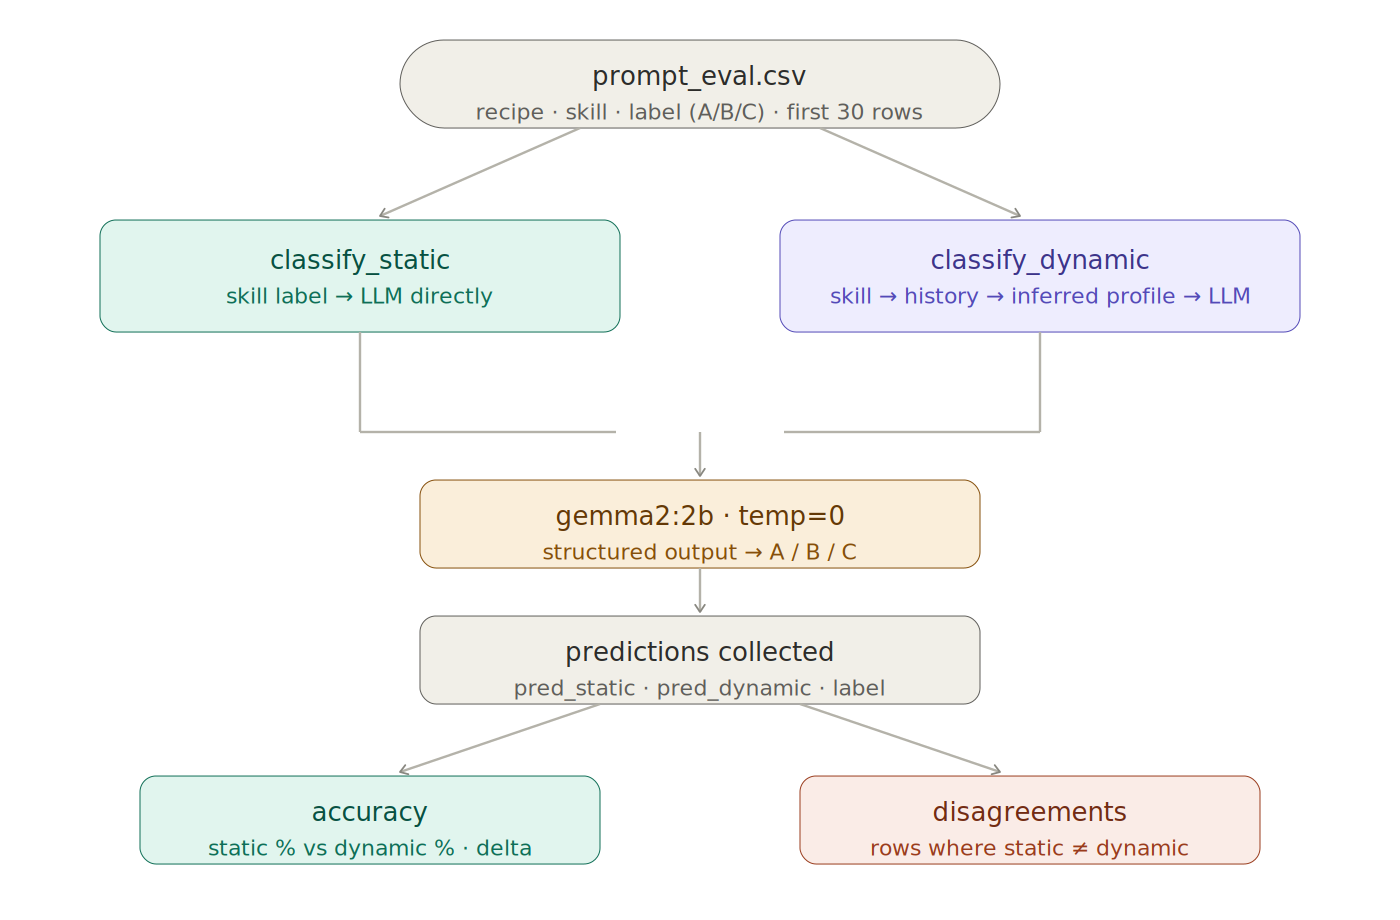

In [19]:
import pandas as pd
from pathlib import Path

# ── Parameters ────────────────────────────────────────────────────────────────
# Set EVAL_SAMPLE_N to an integer for a quick demo, or None to run the full set.
# At small n the accuracy numbers are illustrative — use None for real conclusions.
EVAL_SAMPLE_N = 5

# ── Load eval set ─────────────────────────────────────────────────────────────
eval_path = Path("data/prompt_eval.csv")
if not eval_path.exists():
    print("data/prompt_eval.csv not found — this file is generated in week 4.")
else:
    eval_df = pd.read_csv(eval_path)
    print(f"Loaded {len(eval_df)} examples from prompt_eval.csv")
    print(f"Columns: {list(eval_df.columns)}")
    LABEL_COLS = ["label", "expected", "answer", "target", "ground_truth"]
    label_col = next((c for c in LABEL_COLS if c in eval_df.columns), None)
    if label_col is None:
        raise ValueError(f"No label column found. Expected one of: {LABEL_COLS}. Got: {list(eval_df.columns)}")
    if label_col != "label":
        print(f"⚠️  Using column '{label_col}' as label (expected 'label')")
        eval_df = eval_df.rename(columns={label_col: "label"})
    print(f"Label distribution:\n{eval_df['label'].value_counts().to_string()}")

    # ── Map skill labels to representative cooking histories ──────────────────
    SKILL_TO_HISTORY = {
        "beginner":     user_profiles[user_profiles["user_id"] == "alice"]["cooking_history"].iloc[0],
        "intermediate": user_profiles[user_profiles["user_id"] == "carol"]["cooking_history"].iloc[0],
        "expert":       user_profiles[user_profiles["user_id"] == "bob"]["cooking_history"].iloc[0],
    }

    # Pre-compute dynamic profiles once — there are only 3 unique histories,
    # so calling infer_skill_from_history inside the loop wastes N-3 ChromaDB queries.
    dynamic_profile_cache = {
        skill: infer_skill_from_history(history)
        for skill, history in SKILL_TO_HISTORY.items()
    }

    def classify_static(recipe_name: str, skill: str) -> str:
        """Classify using the static skill label (week 4 baseline)."""
        resp = ollama.chat(
            model="gemma2:2b",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content":
                    f"Recipe: {recipe_name}\nCook's skill level: {skill}\nHow long will this take?"},
            ],
            format=RecipeClassification.model_json_schema(),
            options={"temperature": 0},
        )
        return json.loads(resp.message.content)["time_category"]

    def classify_dynamic(recipe_name: str, skill: str) -> str:
        """Classify using dynamically inferred skill profile (week 6)."""
        profile = dynamic_profile_cache.get(skill, dynamic_profile_cache["intermediate"])
        context = (
            f"Based on this user's cooking history, their effective skill level is "
            f"{profile['inferred_skill']}. {profile['skill_notes']}"
        )
        resp = ollama.chat(
            model="gemma2:2b",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content":
                    f"Recipe: {recipe_name}\n{context}\nHow long will this take?"},
            ],
            format=RecipeClassification.model_json_schema(),
            options={"temperature": 0},
        )
        return json.loads(resp.message.content)["time_category"]

    # ── Run both versions ────────────────────────────────────────────────────
    sample = (eval_df.head(EVAL_SAMPLE_N) if EVAL_SAMPLE_N is not None else eval_df).copy()
    skill_col = "skill" if "skill" in sample.columns else "cook_skill"

    print(f"\nRunning eval on {len(sample)} examples (static vs dynamic)...")
    static_preds  = []
    dynamic_preds = []

    for _, row in sample.iterrows():
        skill = row[skill_col] if skill_col in row else "intermediate"
        static_preds.append(classify_static(row["recipe"], skill))
        dynamic_preds.append(classify_dynamic(row["recipe"], skill))

    sample["pred_static"]  = static_preds
    sample["pred_dynamic"] = dynamic_preds

    # ── Report ───────────────────────────────────────────────────────────────
    static_acc  = (sample["pred_static"]  == sample["label"]).mean()
    dynamic_acc = (sample["pred_dynamic"] == sample["label"]).mean()

    print(f"\n{'Method':<20} {'Accuracy':>10}")
    print("-" * 32)
    print(f"{'Static label':<20} {static_acc:>9.1%}")
    print(f"{'Dynamic profile':<20} {dynamic_acc:>9.1%}")

    diff = dynamic_acc - static_acc
    direction = "improvement" if diff >= 0 else "regression"
    print(f"\nDynamic context: {abs(diff):.1%} {direction} over static label")

    # Show cases where the two methods disagree
    disagree = sample[sample["pred_static"] != sample["pred_dynamic"]]
    if len(disagree) > 0:
        print(f"\nDisagreements ({len(disagree)} cases):")
        for _, row in disagree.head(5).iterrows():
            skill = row[skill_col] if skill_col in row else "?"
            print(f"  {row['recipe'][:40]:<40} skill={skill:<14} "
                  f"static={row['pred_static']}  dynamic={row['pred_dynamic']}  truth={row['label']}")
    else:
        print("\nNo disagreements — both methods give identical predictions on this sample.")

    # ── Robustness Eval — mismatched users ───────────────────────────
    # These users' cooking histories suggest a different skill level
    # than their stated label. Dynamic inference should correct this.
    print("\n" + "=" * 50)
    print("ROBUSTNESS EVAL — Mismatched Users")
    print("=" * 50)

    MISMATCH_USERS = [
        {
            "recipe": "Pasta Carbonara",
            "stated_skill": "beginner",
            "actual_history": (
                "beef wellington (2 times), homemade croissants (3 times), "
                "hollandaise sauce (5 times — consistent success)"
            ),
            "expected": "B",
            "note": "History suggests expert, labeled as beginner",
        },
        {
            "recipe": "Scrambled Eggs",
            "stated_skill": "expert",
            "actual_history": (
                "scrambled eggs (2 attempts — burnt both times), "
                "instant ramen (10 times), microwave popcorn (5 times)"
            ),
            "expected": "A",
            "note": "History suggests beginner, labeled as expert",
        },
        {
            "recipe": "Croissants",
            "stated_skill": "intermediate",
            "actual_history": (
                "croissants (4 successful attempts), soufflé (2 times), "
                "homemade pasta (6 times), tempura (3 times)"
            ),
            "expected": "C",
            "note": "History suggests advanced, labeled as intermediate",
        },
    ]

    mismatch_static = []
    mismatch_dynamic = []

    for user in MISMATCH_USERS:
        s_pred = classify_static(user["recipe"], user["stated_skill"])
        d_pred = classify_dynamic(user["recipe"], user["stated_skill"])
        mismatch_static.append(s_pred)
        mismatch_dynamic.append(d_pred)

    def classify_dynamic_with_history(recipe_name, cooking_history):
        profile = infer_skill_from_history(cooking_history)
        context = (
            f"Based on this user's cooking history, their effective skill level is "
            f"{profile['inferred_skill']}. {profile['skill_notes']}"
        )
        resp = ollama.chat(
            model="gemma2:2b",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content":
                    f"Recipe: {recipe_name}\n{context}\nHow long will this take?"},
            ],
            format=RecipeClassification.model_json_schema(),
            options={"temperature": 0},
        )
        return json.loads(resp.message.content)["time_category"]

    # Re-run dynamic with actual history (not the stated skill)
    mismatch_dynamic_history = []
    for user in MISMATCH_USERS:
        d_pred = classify_dynamic_with_history(user["recipe"], user["actual_history"])
        mismatch_dynamic_history.append(d_pred)

    print(f"\n{'Recipe':<25} {'Stated':<12} {'Static':<8} {'Dyn(label)':<12} {'Dyn(history)':<14} {'Truth':<6} Note")
    print("-" * 95)
    for i, user in enumerate(MISMATCH_USERS):
        print(
            f"{user['recipe']:<25} {user['stated_skill']:<12} "
            f"{mismatch_static[i]:<8} {mismatch_dynamic[i]:<12} "
            f"{mismatch_dynamic_history[i]:<14} {user['expected']:<6} {user['note']}"
        )

    # Robustness accuracy (dynamic with actual history vs truth)
    rob_correct = sum(1 for i, u in enumerate(MISMATCH_USERS) if mismatch_dynamic_history[i] == u["expected"])
    print(f"\nRobustness accuracy (dynamic w/ history): {rob_correct}/{len(MISMATCH_USERS)}")
    print("Key insight: when stated skill mismatches actual skill, dynamic inference from history can correct.")


Loaded 21 examples from prompt_eval.csv
Columns: ['recipe', 'label', 'skill']
Label distribution:
label
B    8
A    7
C    6

Running eval on 5 examples (static vs dynamic)...

Method                 Accuracy
--------------------------------
Static label             60.0%
Dynamic profile          40.0%

Dynamic context: 20.0% regression over static label

Disagreements (1 cases):
  Grilled Cheese Sandwich                  skill=beginner       static=A  dynamic=B  truth=A

ROBUSTNESS EVAL — Mismatched Users

Recipe                    Stated       Static   Dyn(label)   Dyn(history)   Truth  Note
-----------------------------------------------------------------------------------------------
Pasta Carbonara           beginner     B        B            B              B      History suggests expert, labeled as beginner
Scrambled Eggs            expert       B        B            A              A      History suggests beginner, labeled as expert
Croissants                intermediate B       

---
## Beyond What We Built

While we have covered a lot of the basics of a RAG pipeline, it can take various shapes depending on the problem and there are a lot of levers to play with, like:

### Chunking Strategies

We used paragraph/semantic chunking above because the document structure gave us natural boundaries. That choice doesn't always work. Here's the full trade-off table:

| Strategy | How | Best for | Risk |
|---|---|---|---|
| **Fixed-size** | Every N tokens, with overlap | Uniform, unstructured text | Splits mid-sentence or mid-concept |
| **Sentence boundary** | Split at `.` / `?` / `!` | Prose text | Uneven chunk sizes; short sentences lose context |
| **Semantic/paragraph** | Split at headings / blank lines | Structured documents with clear sections | Requires good source structure; fails on unformatted text |
| **Recursive** | Try paragraph → sentence → word until chunk fits size limit | Mixed / unpredictable documents | More complex to implement; adds latency |


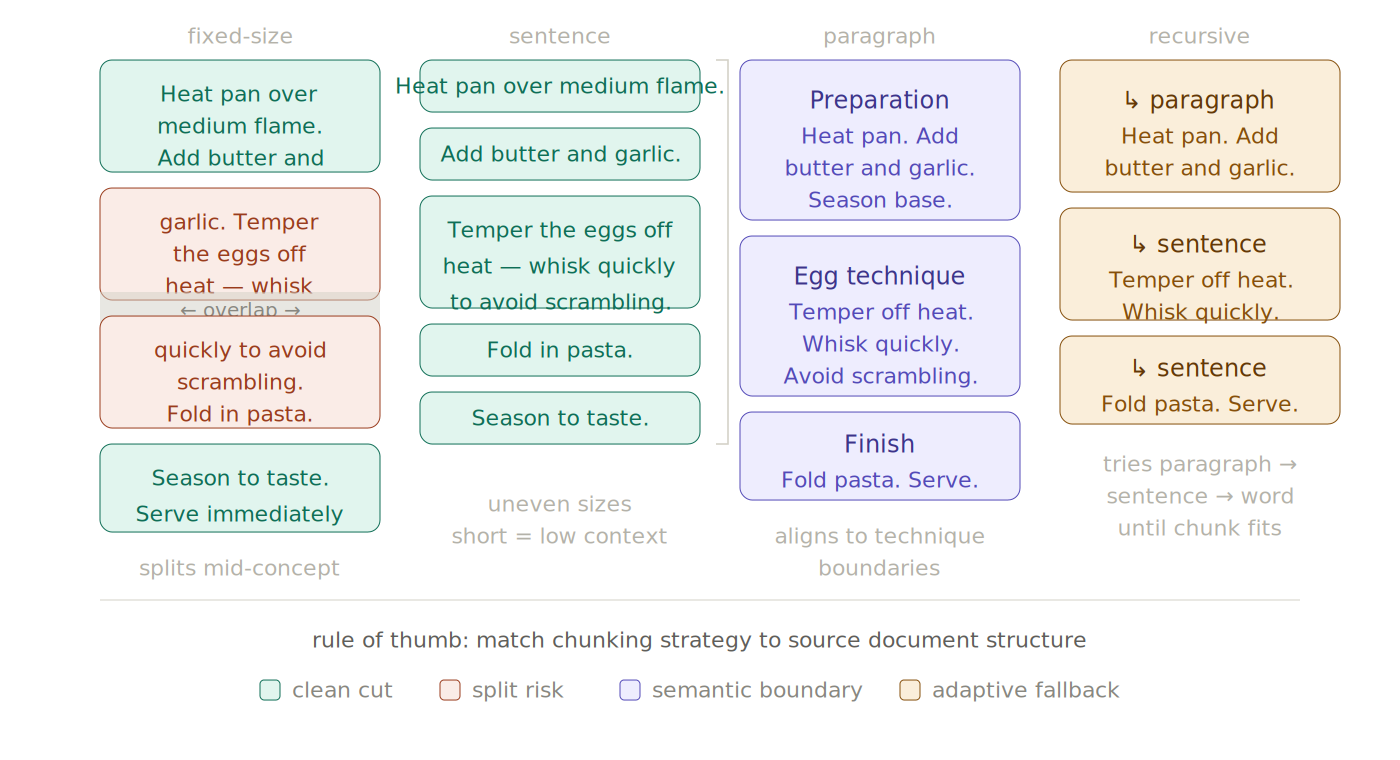

**Rule of thumb:** match the chunking strategy to the structure of your source document.
- Well-structured (headings, sections) → semantic/paragraph
- Prose (articles, transcripts) → sentence-boundary or recursive
- No structure (raw logs, exports) → fixed-size with overlap

**Overlap:** fixed-size chunking often uses a sliding window (e.g., 512 tokens with 64-token overlap). This ensures that sentences cut at a boundary appear in full in at least one chunk — useful when you can't predict where a query's answer will fall.

---
### Hybrid Search

The ChromaDB queries we ran above use **dense retrieval**: the query and documents are embedded as vectors, and we find the nearest vectors by cosine similarity. Dense retrieval understands semantic meaning — "why does the sauce break?" matches "emulsification" even though those words don't overlap.

Dense retrieval has a known failure mode: **rare or domain-specific terms**. If a user asks about "deglazing" and that exact term is underrepresented in the embedding model's training data, the embedding won't capture it well. **Sparse retrieval (BM25)** solves this: it matches on exact keywords, so "deglazing" will always match a chunk that contains the word "deglaze."

**Hybrid search** combines both:

1. Dense retrieval returns a ranked list of top-k chunks
2. BM25 returns a separate ranked list of top-k chunks  
3. **Reciprocal Rank Fusion (RRF)** merges them by position: a chunk that appears at rank 2 in both lists scores higher than one that appears at rank 1 in only one


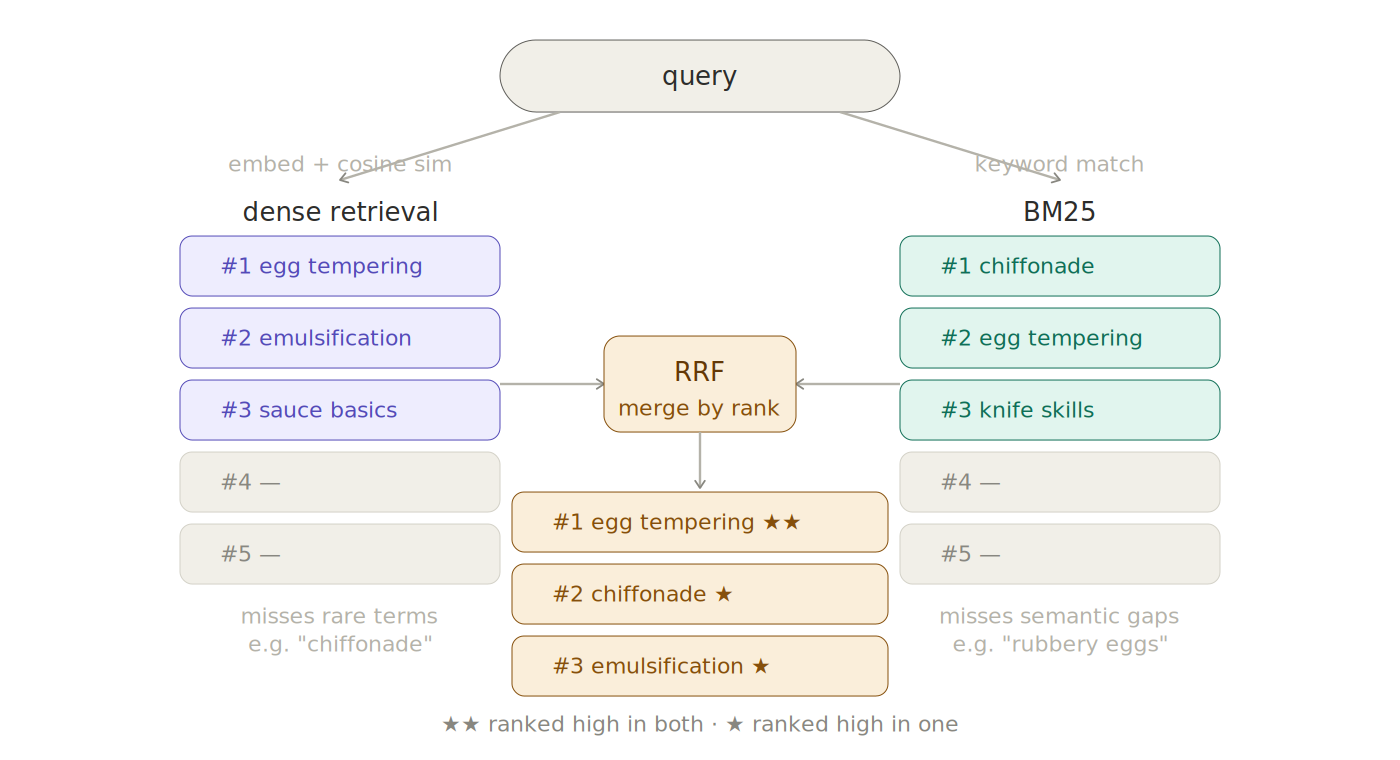

**When it matters for our use case:** if a user asks about a very specific technique name they just learned ("I want to practice chiffonade"), BM25 finds it by keyword while dense search might miss it. If a user asks "how do I stop eggs from going rubbery?", dense search finds the egg-tempering chunk while BM25 finds nothing ("rubbery" isn't in the document). Combined, you're more robust to both types of failure.

---
### Re-ranking

Retrieval gives you the top-10 most similar chunks. But "similar" (cosine distance between independent embeddings) is not the same as "relevant" (does this chunk actually answer the query).

**Re-ranking** adds a second pass: a **cross-encoder** reads the query and each candidate chunk *together* and scores them on true relevance.

| | Bi-encoder (retrieval) | Cross-encoder (re-ranking) |
|---|---|---|
| **How** | Query and document embedded independently | Query + document concatenated and read jointly |
| **Attention** | No cross-attention between query and document | Full attention across both |
| **Speed** | Fast — chunk embeddings pre-computed | Slow — must re-read query + chunk at inference time |
| **Accuracy** | Good for top-k retrieval | Higher for final ranking |
| **When** | Index of millions of chunks | Top-10 from initial retrieval |

The standard pattern: bi-encoder retrieves top-20 at millisecond speed, cross-encoder re-ranks them and returns top-3 at second-level latency. Users see the re-ranked result; the bi-encoder's imprecision is hidden.


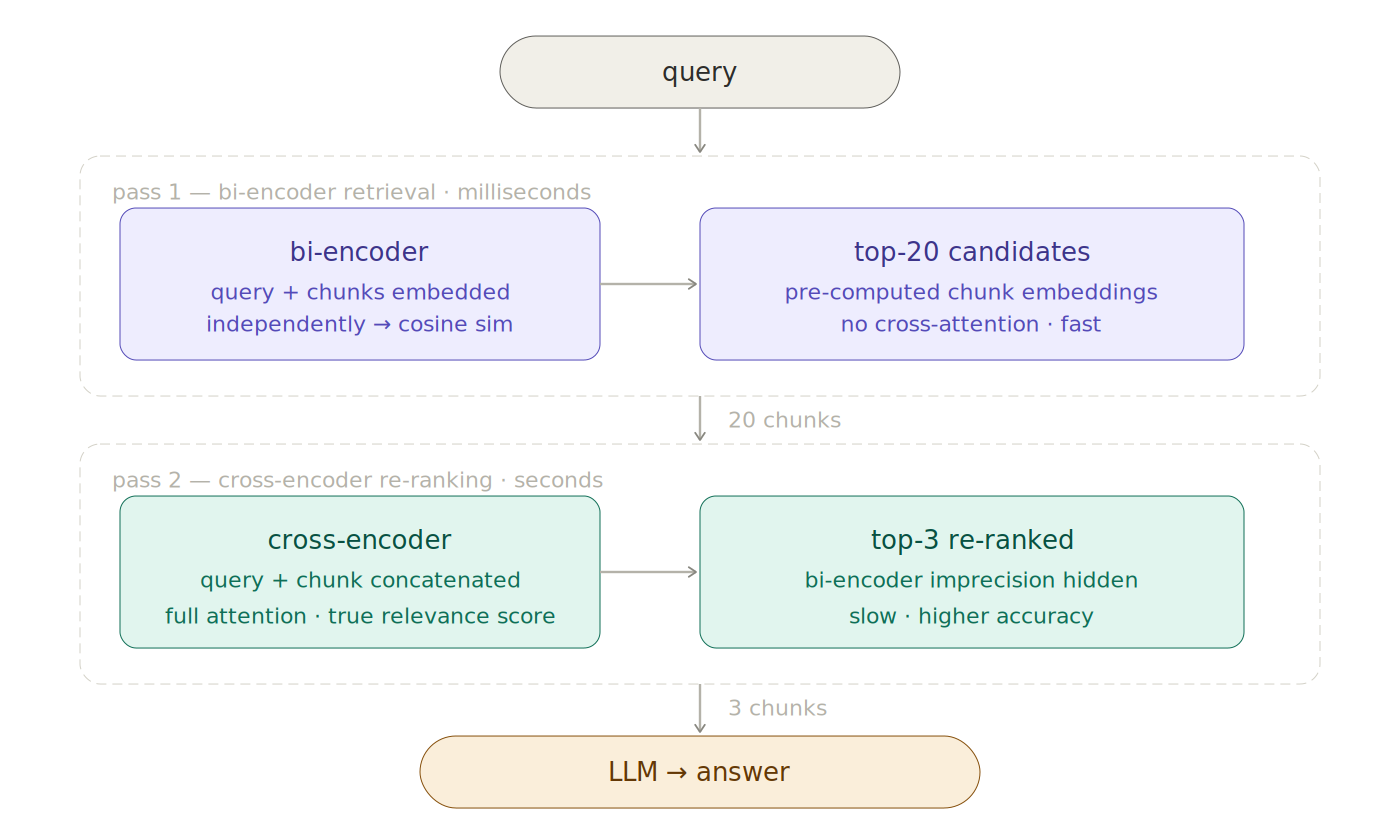

**Finding re-ranking models:** the [MTEB Leaderboard → Reranking tab](https://huggingface.co/spaces/mteb/leaderboard) ranks cross-encoders by domain. For general English text, models like `cross-encoder/ms-marco-MiniLM-L-6-v2` are widely used and small enough to run locally.

---
### RAG architecture evolution

How RAG systems grow from a simple retrieve-and-read loop into a fully modular pipeline with routing, evaluation, and fallback logic.

#### Naive RAG

The simplest form: embed the query, find the nearest chunks by cosine similarity, stuff them into the prompt, call the LLM.


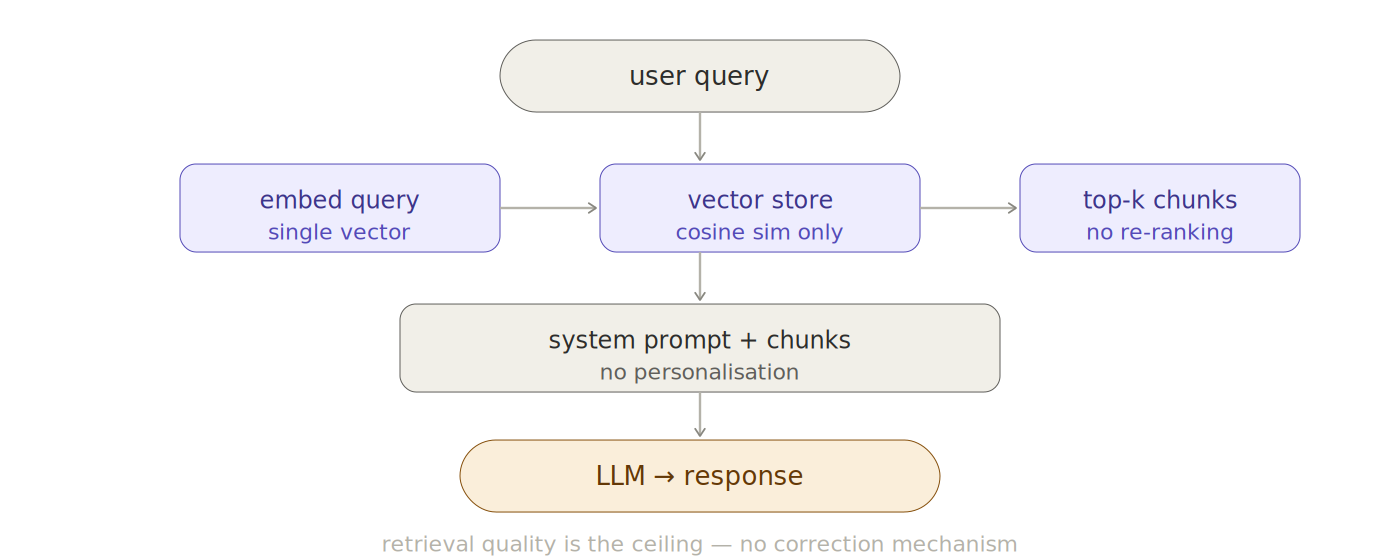


Works well for straightforward, well-structured document sets. The core limitation is that retrieval quality is the ceiling — if the wrong chunk comes back, nothing in the pipeline catches or corrects it. One vector store, one pass, no feedback.

#### Advanced RAG

Adds robustness at retrieval and richness at the prompt level. Instead of a single dense retrieval path, the query goes through both dense (semantic) and sparse (BM25 keyword) retrieval in parallel. Reciprocal Rank Fusion merges the two ranked lists, a metadata filter narrows the candidates, and a cross-encoder re-ranker does a second-pass relevance score before anything reaches the LLM.


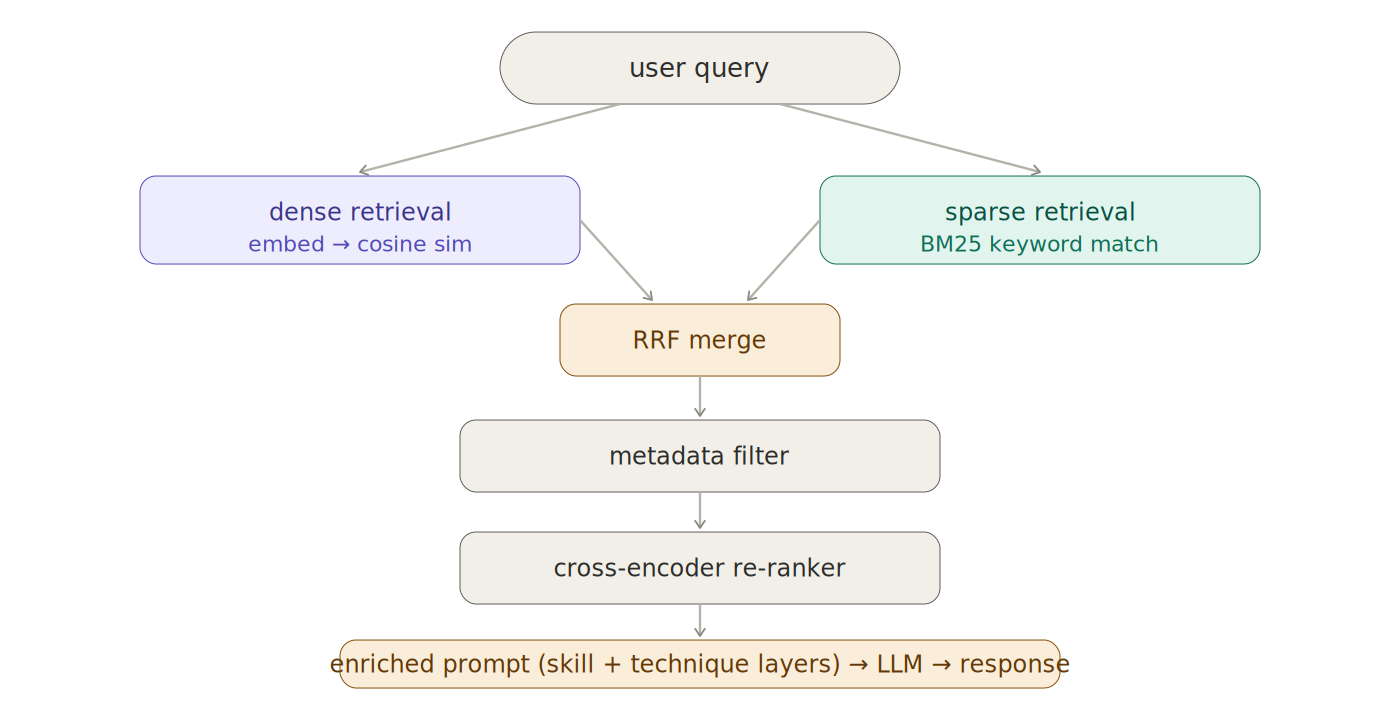


This is where most course projects should land. The pipeline still makes a single pass — no loops — but it is far more robust to the two main retrieval failure modes: semantic gaps (rare terms BM25 catches) and vocabulary mismatches (semantic meaning dense retrieval catches).

#### Modular RAG

Production systems add routing, evaluation loops, and fallback logic. A query router decides which retriever(s) to call. An evaluator checks whether the retrieved context is actually relevant before building the prompt. If not, it falls back to an alternative source or web search. An output evaluator at the end checks the response quality and can trigger a retry.


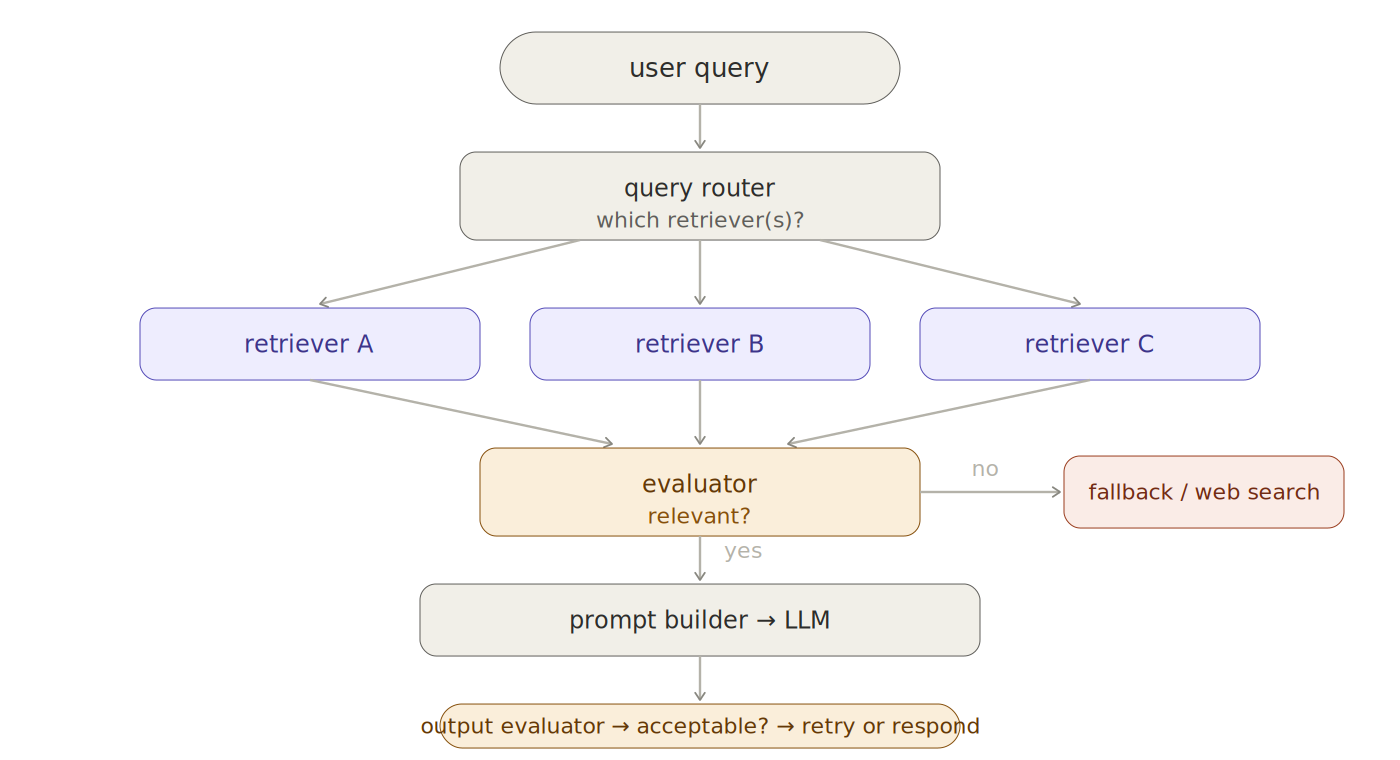


Every component is swappable — you can change the router logic, add a retriever, or replace the evaluator without rebuilding the rest. The added complexity is only worth it at scale or when retrieval failure has high stakes (medical, legal, compliance). For most assignment use cases, Advanced RAG is the right target.

> **Where most course projects land:** Advanced RAG. Hybrid search + metadata filter + one or two retrieval layers covers the vast majority of real-world improvement over Naive RAG without the operational overhead of a full Modular system.

---

## Key Takeaways

- **RAG is a retrieval design problem.** The question isn't "should I use RAG?" but "what context changes per query, and where does it live?"
- **Multiple retrieval layers compose cleanly.** Layer 1 (user profile) and Layer 2 (domain knowledge) use the same ChromaDB interface but serve different purposes — keeping them in separate collections prevents schema and semantic bleed.
- **Metadata is a first-class retrieval tool.** Filtering by `technique_type`, `difficulty`, or `skill_level` before ranking is cheaper and more precise than relying on embedding distance alone.
- **Hybrid search (dense + sparse) covers different failure modes.** Dense retrieval finds semantically similar content; BM25 finds exact keyword matches. Reciprocal Rank Fusion (RRF) merges both without needing a tuned weight.
- **Re-ranking is a second opinion.** A cross-encoder re-reads the query alongside each candidate chunk — slower than embedding distance but far more accurate for final selection.
- **Dynamic context beats static labels when evidence is richer.** Inferring skill from cooking history gives the model a richer signal than a hand-typed label, at the cost of needing a reference corpus to query against.

---

**Your assignment:**

1. Identify one piece of context your classifier currently hardcodes or lacks entirely — something that changes per query or per user
2. Design a retrieval layer for it: what's the data source, how will you chunk or embed it, and what metadata will you attach?
3. Build the layer using the patterns from this notebook and evaluate whether dynamic context improves accuracy relative to your Module 5 adapter baseline

To start your assignment, run in the Claude Code terminal:
```
Use assignment-partner skill to help me with this week's work.
```